**MLP Classifier - Binary**

**Import required libraries**

In [19]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier
from numpy import arange
from sklearn.model_selection import GridSearchCV

In [20]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 9 - Neural Network/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
data.shape

(768, 9)

Outcome
0    500
1    268
Name: count, dtype: int64


<Axes: xlabel='Outcome', ylabel='count'>

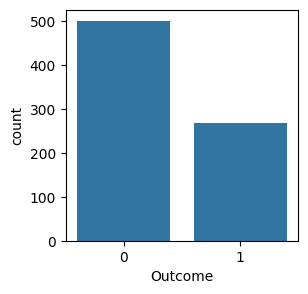

In [22]:
print(data["Outcome"].value_counts())
plt.figure(figsize = (3,3))
sns.countplot(x = 'Outcome', data = data)

In [23]:
x = data.drop('Outcome', axis = 1)
y = data['Outcome']

In [24]:
# Data Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Class Balancing**

In [25]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train, y_train = smote.fit_resample(x_train, y_train)

In [26]:
y_train.value_counts()

Outcome
0    401
1    401
Name: count, dtype: int64

**Normalization**

In [27]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Neural network module

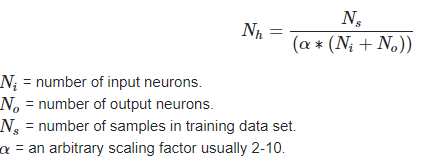

**MLP Classifier**

In [ ]:
mlp = MLPClassifier(max_iter = 1000) 

mlp.fit(x_train, y_train)
y_pred = mlp.predict(x_test)
 
mlp_acc = accuracy_score(y_test, y_pred)
mlp_pre = precision_score(y_test, y_pred, average = 'weighted')
mlp_recall = recall_score(y_test, y_pred, average = 'weighted')
mlp_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("MLP - Accuracy: {:.3f}.".format(mlp_acc))
print("MLP - Precision: {:.3f}.".format(mlp_pre))
print("MLP - Recall: {:.3f}.".format(mlp_recall))
print("MLP - F1_Score: {:.3f}.".format(mlp_f1))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print ('\n Clasification Report:\n', classification_report(y_test, y_pred))

MLP - Accuracy: 0.675.
MLP - Precision: 0.716.
MLP - Recall: 0.675.
MLP - F1_Score: 0.682.

Confusion Matrix: 
 [[63 36]
 [14 41]]

 Clasification Report:
               precision    recall  f1-score   support

           0       0.82      0.64      0.72        99
           1       0.53      0.75      0.62        55

    accuracy                           0.68       154
   macro avg       0.68      0.69      0.67       154
weighted avg       0.72      0.68      0.68       154



In [29]:
mlp.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (100,),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

**MLP Classifier - 3 HL (DNN)**

In [30]:
mlp = MLPClassifier(hidden_layer_sizes = (256, 128, 64), max_iter = 1000)

mlp.fit(x_train, y_train)
y_pred = mlp.predict(x_test)
 
mlp_acc = accuracy_score(y_test, y_pred)
mlp_pre = precision_score(y_test, y_pred, average = 'weighted')
mlp_recall = recall_score(y_test, y_pred, average = 'weighted')
mlp_f1 = f1_score(y_test, y_pred, average = 'weighted')
 
print("MLP - Accuracy: {:.3f}.".format(mlp_acc))
print("MLP - Precision: {:.3f}.".format(mlp_pre))
print("MLP - Recall: {:.3f}.".format(mlp_recall))
print("MLP - F1_Score: {:.3f}.".format(mlp_f1))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print ('\n Clasification Report:\n', classification_report(y_test,y_pred))

MLP - Accuracy: 0.727.
MLP - Precision: 0.753.
MLP - Recall: 0.727.
MLP - F1_Score: 0.733.

Confusion Matrix: 
 [[70 29]
 [13 42]]

 Clasification Report:
               precision    recall  f1-score   support

           0       0.84      0.71      0.77        99
           1       0.59      0.76      0.67        55

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.75      0.73      0.73       154



**MLP Classifier with GridSearchCV**

In [31]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)  

mlp = MLPClassifier(hidden_layer_sizes = (256, 128, 64), max_iter = 50000)
 
parameters = {
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'solver' : ['sgd', 'adam'],
    'learning_rate' : ['constant', 'invscaling', 'adaptive'],
    'random_state' : arange(0, 5, 1)
    }

mlp_g = GridSearchCV(estimator = mlp, param_grid = parameters, scoring = 'accuracy', cv = skf)

mlp_g.fit(x_train, y_train)

print("Best Parameters: ", mlp_g.best_params_)
print("Best Score: ", mlp_g.best_score_)

best_model = mlp_g.best_estimator_

y_pred = best_model.predict(x_test)
 
# Get model performances
mlp_r_acc = accuracy_score(y_test, y_pred)
mlp_r_pre = precision_score(y_test, y_pred, average = 'weighted')
mlp_r_recall = recall_score(y_test, y_pred, average = 'weighted')
mlp_r_f1 = f1_score(y_test, y_pred, average = 'weighted')

print("MLP - Accuracy: {:.3f}.".format(mlp_r_acc))
print("MLP - Precision: {:.3f}.".format(mlp_r_pre))
print("MLP - Recall: {:.3f}.".format(mlp_r_recall))
print("MLP - F1_Score: {:.3f}.".format(mlp_r_f1))
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print ('\n Clasification Report:\n', classification_report(y_test, y_pred))

Best Parameters:  {'activation': 'relu', 'learning_rate': 'constant', 'random_state': np.int64(4), 'solver': 'adam'}
Best Score:  0.7905230402295639
MLP - Accuracy: 0.636.
MLP - Precision: 0.698.
MLP - Recall: 0.636.
MLP - F1_Score: 0.643.

Confusion Matrix: 
 [[56 43]
 [13 42]]

 Clasification Report:
               precision    recall  f1-score   support

           0       0.81      0.57      0.67        99
           1       0.49      0.76      0.60        55

    accuracy                           0.64       154
   macro avg       0.65      0.66      0.63       154
weighted avg       0.70      0.64      0.64       154



Sklearn Tuner from Keras Tuner

In [32]:
# %pip install -q -U keras-tuner

In [35]:
import keras_tuner as kt

def build_model(hp):
  model = MLPClassifier(hidden_layer_sizes = (256, 128, 64), max_iter = 10000,
      activation = hp.Choice('activation', ['identity', 'logistic', 'tanh', 'relu']),
      solver = hp.Choice('solver', ['lbfgs', 'sgd', 'adam']),
      learning_rate = hp.Choice('learning_rate', ['constant', 'invscaling', 'adaptive']),
      random_state = hp.Int('random_state', min_value = 0, max_value = 10, step = 1)
  )
  return model

tuner = kt.SklearnTuner(oracle = kt.oracles.BayesianOptimizationOracle(objective = kt.Objective('score', 'max'),
        max_trials = 3), hypermodel = build_model, cv = StratifiedKFold(n_splits = 7, shuffle = True, random_state = 42), overwrite = True)

tuner.search(x_train, y_train.values)

print()
best_model = tuner.get_best_models(num_models=1)[0]
best_model

Trial 3 Complete [00h 00m 57s]
score: 0.7618284842541135

Best score So Far: 0.788035305655443
Total elapsed time: 00h 02m 08s



MLPClassifier(activation='tanh', hidden_layer_sizes=(256, 128, 64),
              learning_rate='invscaling', max_iter=10000, random_state=0,
              solver='lbfgs')